# Lecture 04 - Exercise: Upsampling

In [87]:
#######################
### L04 - Exercises ###
#######################

# importing libraries and setting up nice plots

import os
import random
import numpy                      as     np
import matplotlib.pyplot          as     plt
import matplotlib.patches         as     patches
import matplotlib.ticker		  as     tck
import matplotlib.colors		  as     colors
from   matplotlib				  import rc
from   matplotlib.gridspec		  import GridSpec
from   sys                        import stdout
from   scipy                      import stats, interpolate, integrate
from   astroML.datasets           import fetch_dr7_quasar
from   astropy.cosmology          import Planck15
from   astropy.visualization      import hist
from   astroML.density_estimation import EmpiricalDistribution


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

# did we start this notebook from ".../GitHub/working" directory or from ".../GitHub" (by accident)?
current_pwd = os.getcwd()



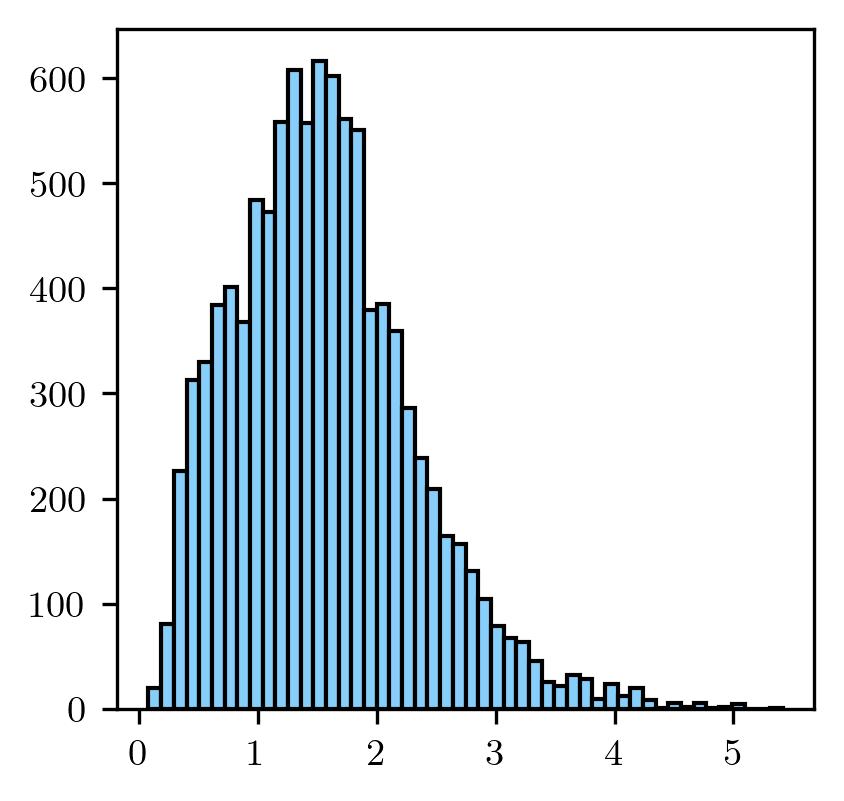

In [88]:
# Fetch quasar data
data = fetch_dr7_quasar()

# Select only the data we wish to use:
data_copy = np.copy(data)
data_copy = data_copy[:10000]
z = data_copy['redshift']

# Extremely quick plot to visualize the dataset we wish to clone
fig , ax = plt.subplots(1,1,figsize=(3,3))
z_histo = ax.hist( z, bins=50, density=False, color='lightskyblue', edgecolor='black')
plt.show()


In [89]:
# Quick investigation for some boundaries and basic stat. properties
z_mean = np.mean(z)
z_max  = np.max(z)
z_min  = np.min(z)
y_max = z_histo[0].max()
z_lower = np.floor(z_min)
z_upper = np.ceil(z_max)

print('z mean = {:.2f}'.format(z_mean))
print('z max  = {:.2f}'.format(z_max))
print('z min  = {:.2f}'.format(z_min))
print('max z count = {:.0f}'.format(y_max))
print('choose lower boundary on z = {:.2f}'.format(z_lower))
print('choose upper boundary on z = {:.2f}'.format(z_upper))


# Show data size and set resampling size 
N_data  = len(z)
N_clone = 100000
print('N_data  = {:d}'.format(N_data))
print('N_clone = {:d} = {:.0f} x N_data'.format(N_clone, N_clone/N_data))



z mean = 1.56
z max  = 5.41
z min  = 0.08
max z count = 616
choose lower boundary on z = 0.00
choose upper boundary on z = 6.00
N_data  = 10000
N_clone = 100000 = 10 x N_data


# Resampling method 1 - Inverse Transform Sampling

In [90]:
#########################################################################
### L04 - Exercise 1: Cloning dataset with Inverse Transform Sampling ###
#########################################################################

### NOTE: we are just showing our understending of the theoretical steps
###       we will then use a built-in function in astropy to clone the data

# create a cumulative distribution from the measured data
z.sort()
cdf_z = np.linspace(0, 1, N_data) 

# set up an interpolation of the inverse cumulative distribution
# note the usage of splrep (spline representation):
# function(var_x) = interpolate.splrep( var_y = cdf(x), var_x = x )
cdf_interpol = interpolate.splrep(cdf_z, z)

# sample evenly (and densely) along the cumulative distribution, and interpolate
# note the usage of splev (spline evaluation):
# var_x' = interpolate.splev( var_y' , func = interpolate.splrep( var_y, var_x ) )
cdf_z_sample = np.linspace(0, 1, N_clone)
z_sample = interpolate.splev(cdf_z_sample, cdf_interpol)

    
#------------------------------------------------------------
# Clone the measured distribution with astroML.density_estimation.EmpiricalDistribution
z_cloned = EmpiricalDistribution(z).rvs(N_clone)

# compute the KS test to check whether the clone data comes from the distribution
D1, p1 = stats.ks_2samp(z, z_cloned)
print("KS test: D = %.10g; p = %.10g" % (D1, p1))

D2, p2 = stats.ks_2samp(z, z_sample)
print("KS test: D = %.10g; p = %.10g" % (D2, p2))


KS test: D = 0.00257; p = 0.9999999839
KS test: D = 0.00028; p = 1


# Resampling method 2 - Monte Carlo Rejection method

In [91]:
# NOTE: cell takes about 40 mins to clone data with N = 10000 = N_data 
# (NOT N extractions some of which are rejected; N accepted extractions)

if False: 
    a , b  = np.histogram(z, bins=50, density=True)
    z_dist = stats.rv_histogram( (a, b) )
    z_rejection = np.zeros(N_data)
    for i in range(N_data):
        rejected = True
        while rejected:
            z_i = np.random.uniform(z_lower,z_upper)
            u_i = np.random.uniform(0, y_max)
            if u_i <= z_dist.pdf(z_i):
                rejected = False
        stdout.write('\rProgress = {:.3f}%'.format(i/N_data*100))    
        z_rejection[i] = z_i

    D3, p3 = stats.ks_2samp(z, z_rejection)
    print("KS test: D = %.10g; p = %.10g" % (D3, p3))
    print(len(z_rejection))

if True:
    a , b  = np.histogram(z, bins=50, density=True)
    z_dist = stats.rv_histogram( (a, b) )
    z_montecarlo = z_dist.rvs(size=N_clone)

    D4, p4 = stats.ks_2samp(z, z_montecarlo)
    print("KS test: D = %.10g; p = %.10g" % (D4, p4))
    print(len(z_montecarlo))

KS test: D = 0.00551; p = 0.9439319934
100000


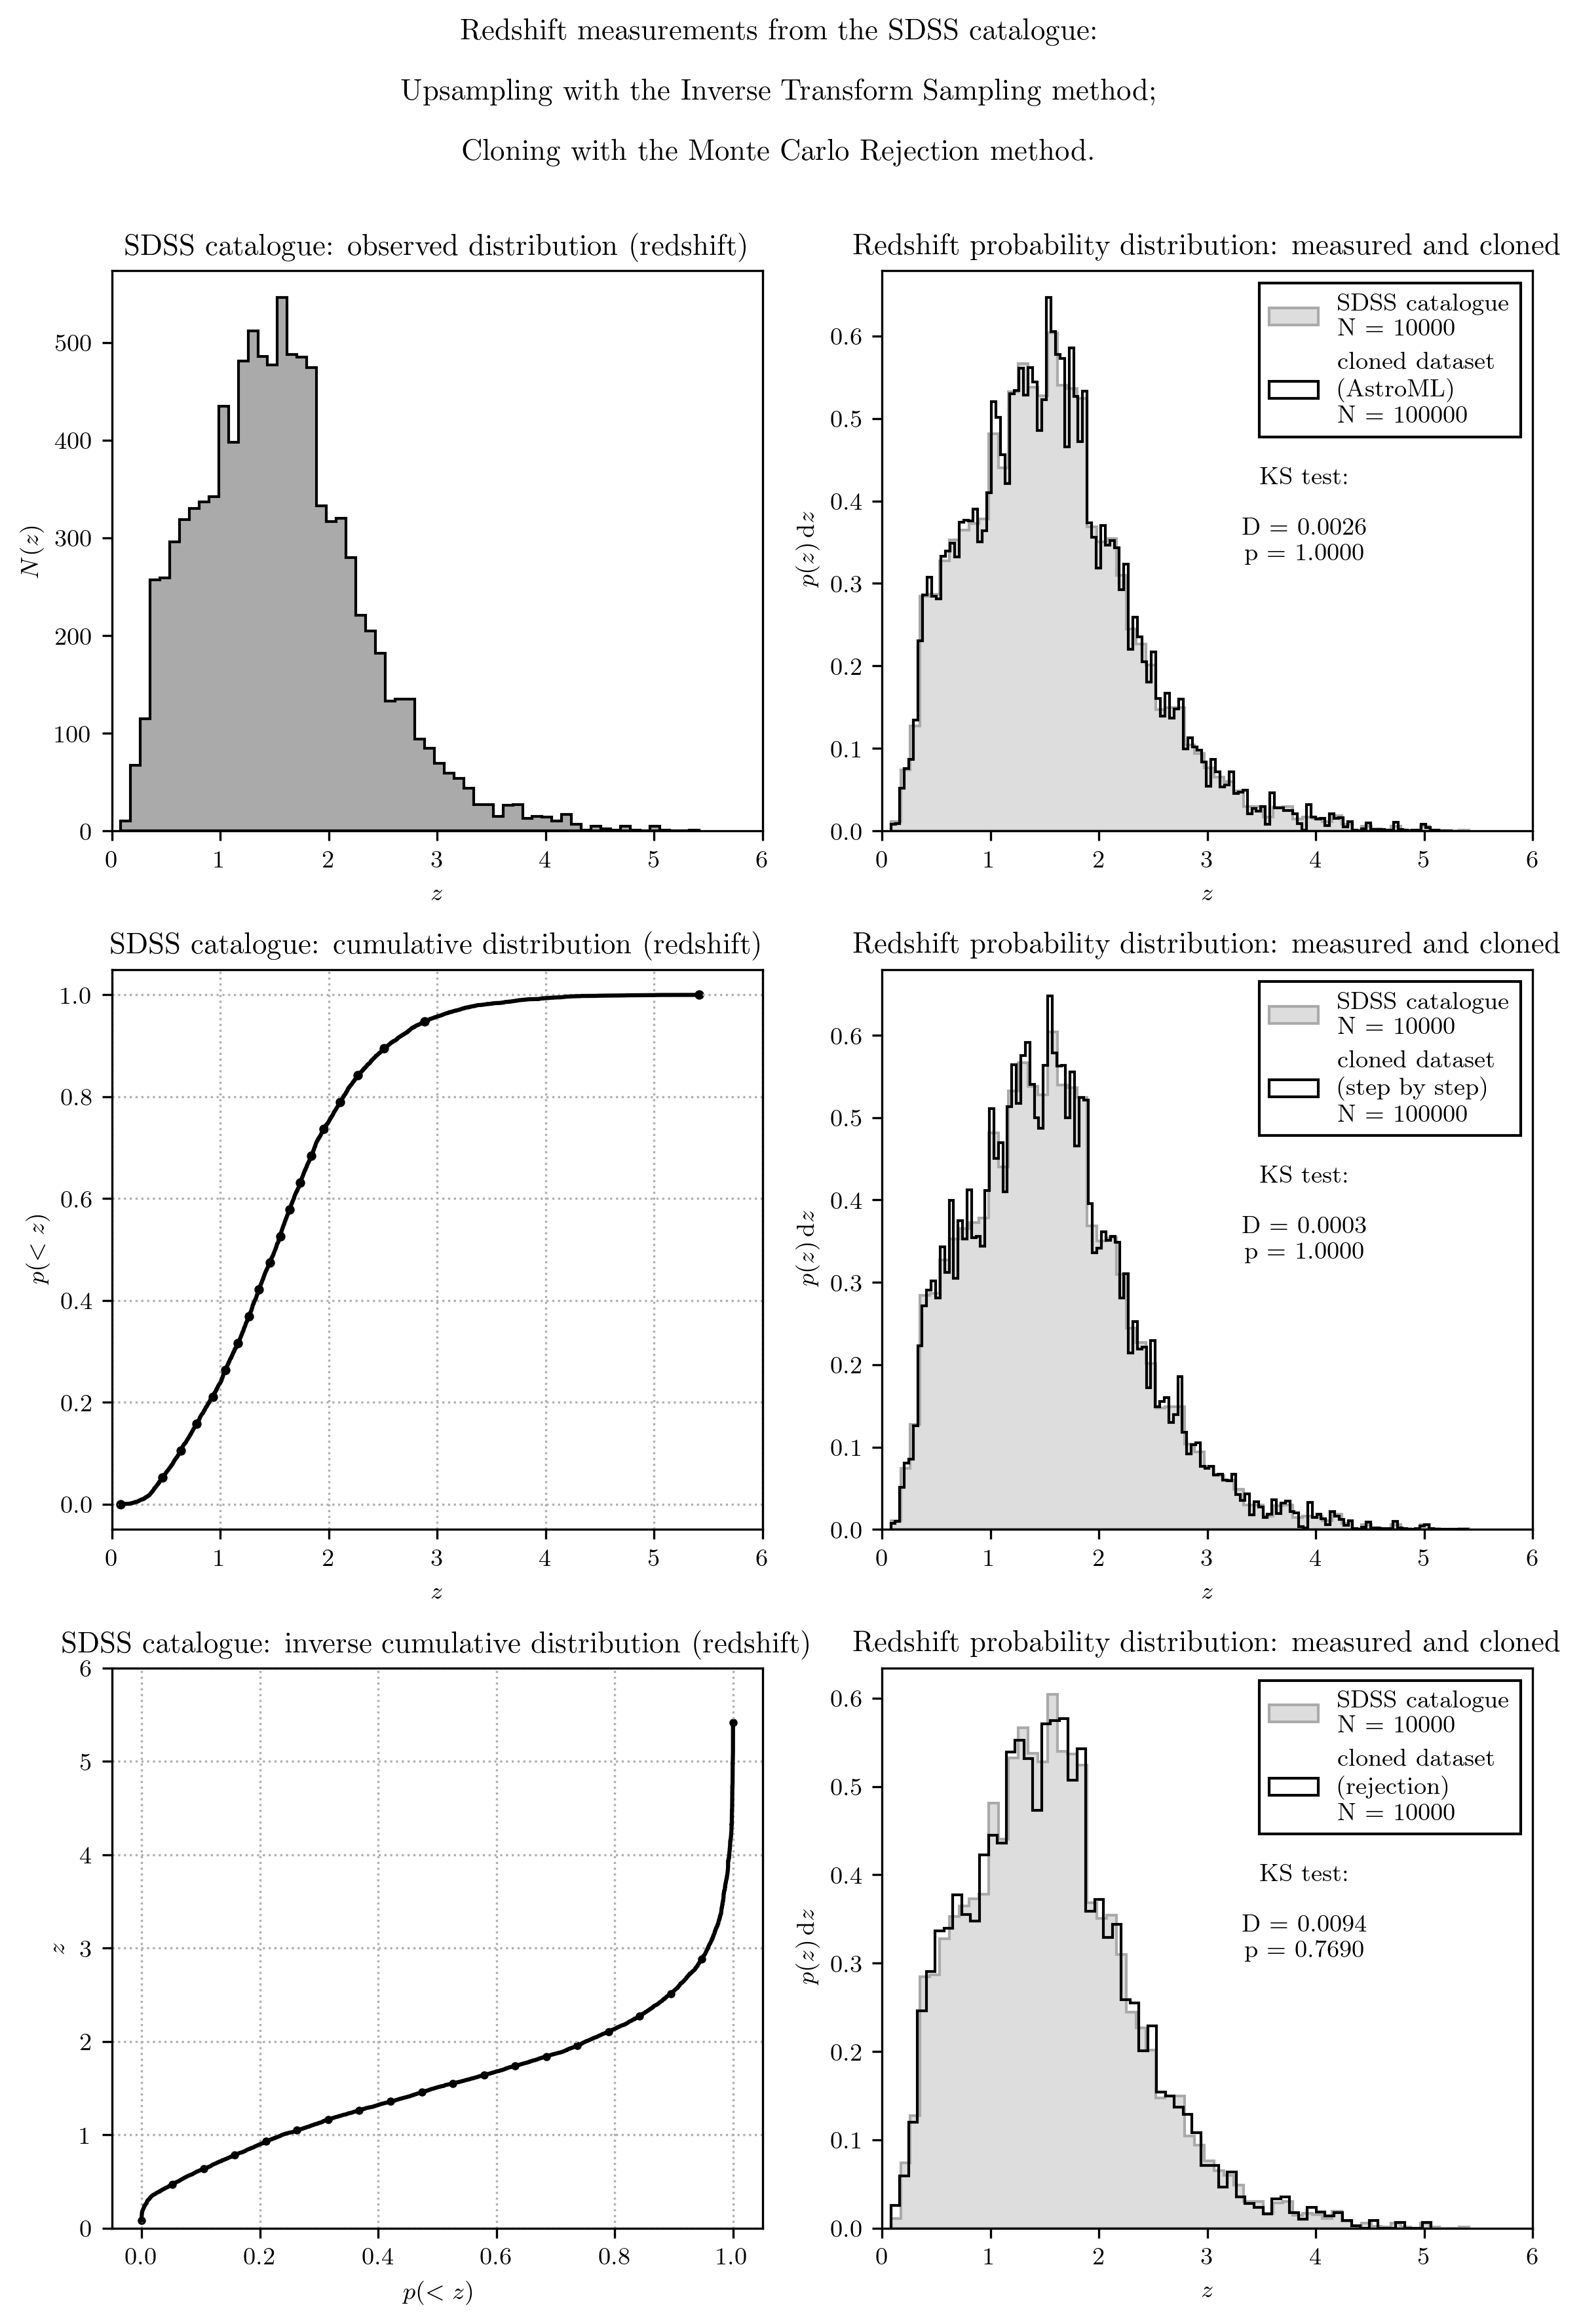

In [126]:
#------------------------------------------------------------
# Plot the cloned distribution and the procedure for obtaining it
fig = plt.figure(figsize=(8, 12))
fig.subplots_adjust(
    hspace = 0.2, # 0.30, 
    left   = 0.0, # 0.10, 
    right  = 0.9, # 0.95, 
    bottom = 0.0, # 0.08, 
    top    = 0.9, # 0.92, 
    wspace = 0.2, # 0.30
)

indices = np.linspace(0, N_data - 1, 20).astype(int)

# plot a histogram of the input
ax = fig.add_subplot(321)
hist(z, bins='knuth', ax=ax, histtype='stepfilled', edgecolor='black', facecolor='#AAAAAA')
ax.set_xlim(z_lower,z_upper)
ax.set_title('SDSS catalogue: observed distribution (redshift)')
ax.set_xlabel('$z$')
ax.set_ylabel('$N(z)$')

# plot the cumulative distribution
ax = fig.add_subplot(323)
ax.scatter(z[indices], cdf_z[indices], linewidth=0, color='black', s=12)   # just the "dots"
ax.plot(z, cdf_z, linestyle='-', color='black') #, '-k') 
ax.set_xlim(z_lower,z_upper)
ax.set_ylim(-0.05, 1.05)
ax.grid(ls=':')
ax.set_title('SDSS catalogue: cumulative distribution (redshift)')
ax.set_xlabel('$z$')
ax.set_ylabel('$p(<z)$')

# plot the inverse cumulative distribution and spline fit
ax = fig.add_subplot(325)
ax.scatter(cdf_z[indices], z[indices], linewidth=0, color='black', s=9)
ax.plot(cdf_z_sample, z_sample, linestyle='-', color='black') #, '-k')
# ax.arrow(0.7, -3.0,  0.00, 3.5, width=0.015, fc='gray', ec='gray', head_width=0.05, head_length=0.40)
# ax.arrow(0.7,  0.9, -0.69, 0.0, width=0.100, fc='gray', ec='gray', head_width=0.30, head_length=0.06)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(z_lower,z_upper)
ax.grid(ls=':')
ax.set_title('SDSS catalogue: inverse cumulative distribution (redshift)')
ax.set_xlabel('$p(<z)$')
ax.set_ylabel('$z$')

# plot the resulting cloned distribution
ax = fig.add_subplot(322)
hist(z, bins='knuth', ax=ax, histtype='stepfilled', density=True, ec='#AAAAAA', fc='#DDDDDD', label='SDSS catalogue' + '\n' + 'N = {:d}'.format(N_data))
hist(z_cloned, bins='knuth', ax=ax, histtype='step', density=True, color='black', label='cloned dataset' + '\n' + '(AstroML)' + '\n' + 'N = {:d}'.format(len(z_cloned)))

ax.set_xlim(z_lower,z_upper)
ax.set_title('Redshift probability distribution: measured and cloned')
ax.set_xlabel('$z$')
ax.set_ylabel(r'$p(z) \, \textup{d}z$')
ax.text(0.65, 0.65, "KS test:\n\nD = %.4f\np = %.4f" % (D1, p1), ha='center', va='top', transform=ax.transAxes)

ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=1)

ax = fig.add_subplot(324)
hist(z, bins='knuth', ax=ax, histtype='stepfilled', density=True, ec='#AAAAAA', fc='#DDDDDD', label='SDSS catalogue' + '\n' + 'N = {:d}'.format(N_data))
hist(z_sample, bins='knuth', ax=ax, histtype='step', density=True, color='black', label='cloned dataset' + '\n' + '(step by step)' + '\n' + 'N = {:d}'.format(len(z_sample)))

ax.set_xlim(z_lower,z_upper)
ax.set_title('Redshift probability distribution: measured and cloned')
ax.set_xlabel('$z$')
ax.set_ylabel(r'$p(z) \, \textup{d}z$')
ax.text(0.65, 0.65, "KS test:\n\nD = %.4f\np = %.4f" % (D2, p2), ha='center', va='top', transform=ax.transAxes)

ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=1)

ax = fig.add_subplot(326)
hist(z, bins='knuth', ax=ax, histtype='stepfilled', density=True, ec='#AAAAAA', fc='#DDDDDD', label='SDSS catalogue' + '\n' + 'N = {:d}'.format(N_data))
hist(z_rejection, bins='knuth', ax=ax, histtype='step', density=True, color='black', label='cloned dataset' + '\n' + '(rejection)' + '\n' + 'N = {:d}'.format(len(z_rejection)))

ax.set_xlim(z_lower,z_upper)
ax.set_title('Redshift probability distribution: measured and cloned')
ax.set_xlabel('$z$')
ax.set_ylabel(r'$p(z) \, \textup{d}z$')
ax.text(0.65, 0.65, "KS test:\n\nD = %.4f\np = %.4f" % (D3, p3), ha='center', va='top', transform=ax.transAxes)

ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=1)


fig.suptitle(
    "Redshift measurements from the SDSS catalogue:" 
    + "\n\n"
    + "Upsampling with the Inverse Transform Sampling method;"
    + "\n\n"
    + "Cloning with the Monte Carlo Rejection method."
    + "\n\n"
)

# do we want to save the figure?
fig.tight_layout()
if True:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L04_images/L04_Cloning_Upsampling_SDSS__Inverse_Transform_Sampling_Method.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L04_images/L04_Cloning_Upsampling_SDSS__Inverse_Transform_Sampling_Method.pdf', bbox_inches='tight')

# Rough interpretation of the observed redshift distribution

Let us first assume a cosmological model: a flat cosmology with non-zero Lambda and cold dark matter $(\Lambda\textup{CDM})$.

We can for example use the model in astropy.cosmology.Planck15 ($\Lambda\textup{CDM}$ model with parameters estimated from Planck 2015).

Let us now first make  rough assumption that quasars are homogenoeusly and isotropically distributed in the Universe:

$ \dfrac{\textup{d}N}{\textup{d}V(z)} = N_0 = \textup{const.}$

Then, the distribution of quasar redshifts should be:

$$
\int \dfrac{\textup{d}N}{\textup{d}V} \, \textup{d}V 
= N_0 \, \int \, \textup{d}V 
= 4\pi \, N_0 \, {\displaystyle \int_{0}^{z^\textup{SDSS}_\textup{max}} } \dfrac{\textup{d}V_{\textup{Plank15}} }{4\pi \, \textup{d}z} \, \textup{d}z
$$

Where one can numerically compute the differential comoving volume per unit steradian with Astropy (accurate only up to redshift $z\sim 5-6$), based on the theory, and then compare it to the observed ones in the SDSS catalogue.

However, aven assuming that all quasars have comparable intrinsic luminosities, the observed flux decreases with the inverse square of the luminosity distance, so it gets progressively harder to observe farther sources, so the measured distribution would be much smaller than the true distribution for larger redshifts. 




In [130]:
print(Planck15)
print()
for zizi in np.linspace(z_lower,z_upper,13):
    print('At redshift z = {:.2f} the differential comoving volume is dV(z) = {:.2e} Mpc^3'.format(zizi, 4*np.pi * Planck15.differential_comoving_volume(zizi).value))

# Note for self: units of differential_comoving_volume method
# 4pi * astropymethod, because dV(z) is in Mpc^3 / steradians (units of solid angle); check:
# print(Planck15.differential_comoving_volume(0.50).unit)

FlatLambdaCDM(name="Planck15", H0=67.7 km / (Mpc s), Om0=0.307, Tcmb0=2.725 K, Neff=3.05, m_nu=[0.   0.   0.06] eV, Ob0=0.0486)

At redshift z = 0.00 the differential comoving volume is dV(z) = 0.00e+00 Mpc^3
At redshift z = 0.50 the differential comoving volume is dV(z) = 1.60e+11 Mpc^3
At redshift z = 1.00 the differential comoving volume is dV(z) = 3.61e+11 Mpc^3
At redshift z = 1.50 the differential comoving volume is dV(z) = 4.75e+11 Mpc^3
At redshift z = 2.00 the differential comoving volume is dV(z) = 5.22e+11 Mpc^3
At redshift z = 2.50 the differential comoving volume is dV(z) = 5.31e+11 Mpc^3
At redshift z = 3.00 the differential comoving volume is dV(z) = 5.21e+11 Mpc^3
At redshift z = 3.50 the differential comoving volume is dV(z) = 5.01e+11 Mpc^3
At redshift z = 4.00 the differential comoving volume is dV(z) = 4.78e+11 Mpc^3
At redshift z = 4.50 the differential comoving volume is dV(z) = 4.53e+11 Mpc^3
At redshift z = 5.00 the differential comoving volume is dV(z) = 4.28e+

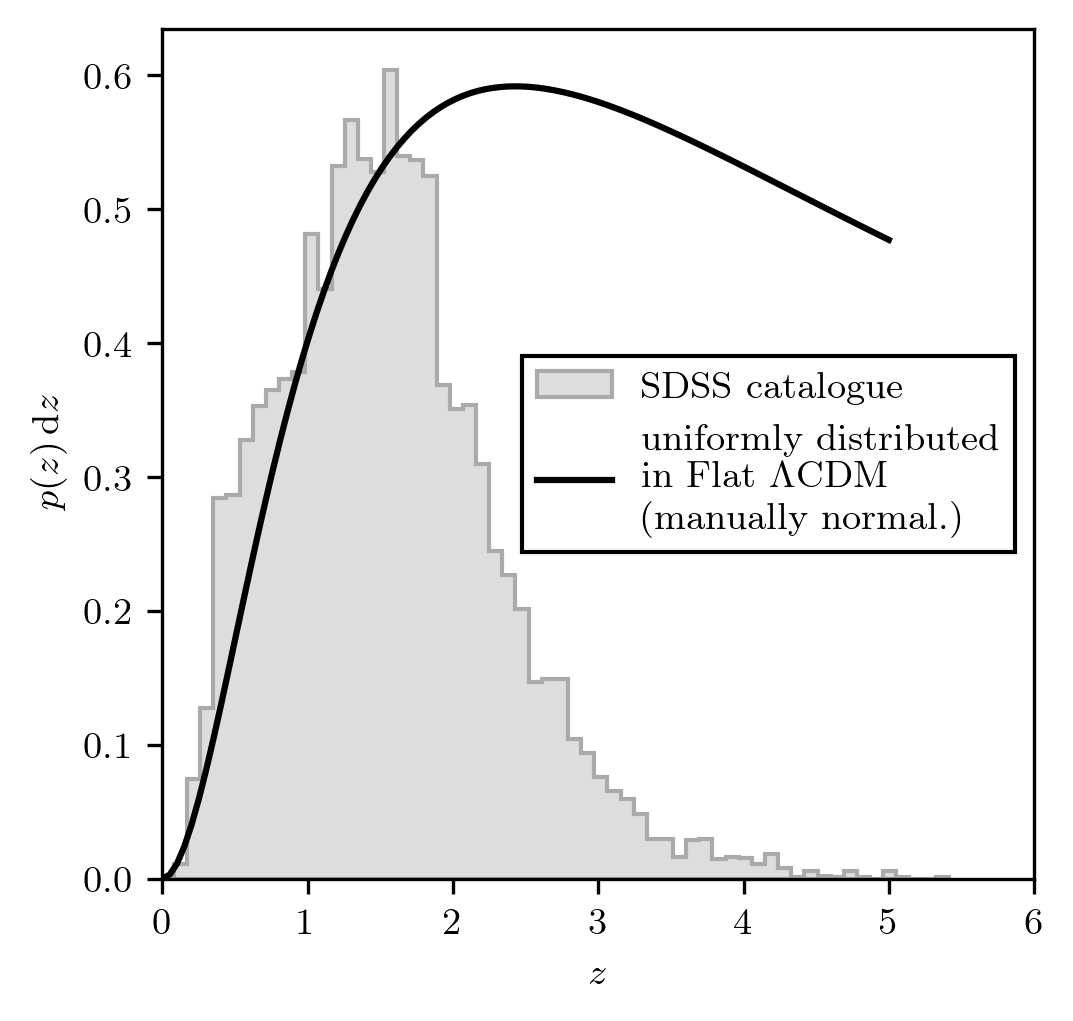

In [152]:
def distrib_theory(var_z):
    return 4*np.pi * Planck15.differential_comoving_volume( var_z ).value

def distrib_normal(var_z, var_min = z_lower, var_max = z_upper):
    return integrate.quad( distrib_theory, var_min, var_max )[0]

def distrib_theory_normal(var_z, var_min = z_lower, var_max = z_upper):
    return distrib_theory(var_z) / distrib_normal(var_z, var_min = z_lower, var_max = z_upper)

zz = np.linspace(0,5,int(N_data/100))
yy = distrib_theory_normal(zz, var_min=0, var_max=5)

fig = plt.figure(figsize=(3.75, 3.75))
ax  = fig.add_subplot(111)

ax.set_xlim(z_lower,z_upper)
# ax.set_title('Redshift probability distribution: measured and cloned')
ax.set_xlabel('$z$')
ax.set_ylabel(r'$p(z) \, \textup{d}z$')

hist(z, bins='knuth', ax=ax, histtype='stepfilled', density=True, ec='#AAAAAA', fc='#DDDDDD', label='SDSS catalogue')
ax.plot(zz, 2.8*yy, color='black', label='uniformly distributed\n' + r'in Flat $\Lambda$CDM' + '\n' + '(manually normal.)') ###   Arbitrary normalization, just matching by eye

ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=5)